In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('crime_aggregated.csv')
df.head()

,district,primary_type,hour,dow,month,n_incidents,arrest_rate,label_arrest_high
0,9,THEFT,11,7,12,41,0.073171,0
1,14,THEFT,13,6,2,41,0.097561,0
2,3,BATTERY,4,1,12,41,0.243902,0
3,7,NARCOTICS,20,7,2,41,1.000000,1
4,4,NARCOTICS,20,6,1,41,1.000000,1


In [3]:
df.describe()

,district,hour,dow,month,n_incidents,arrest_rate,label_arrest_high
count,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000,133123.000000
mean,10.885121,13.573109,4.030348,6.552557,38.540448,0.226057,0.108253
std,6.951240,6.616445,1.983525,3.343256,21.132797,0.278958,0.310701
min,1.000000,0.000000,1.000000,1.000000,20.000000,0.000000,0.000000
25%,5.000000,10.000000,2.000000,4.000000,24.000000,0.065217,0.000000
50%,9.000000,14.000000,4.000000,7.000000,31.000000,0.137255,0.000000
75%,16.000000,19.000000,6.000000,9.000000,46.000000,0.234043,0.000000
max,25.000000,23.000000,7.000000,12.000000,216.000000,1.000000,1.000000


In [4]:
df.dtypes

district               int64
primary_type          object
hour                   int64
dow                    int64
month                  int64
n_incidents            int64
arrest_rate          float64
label_arrest_high      int64
dtype: object

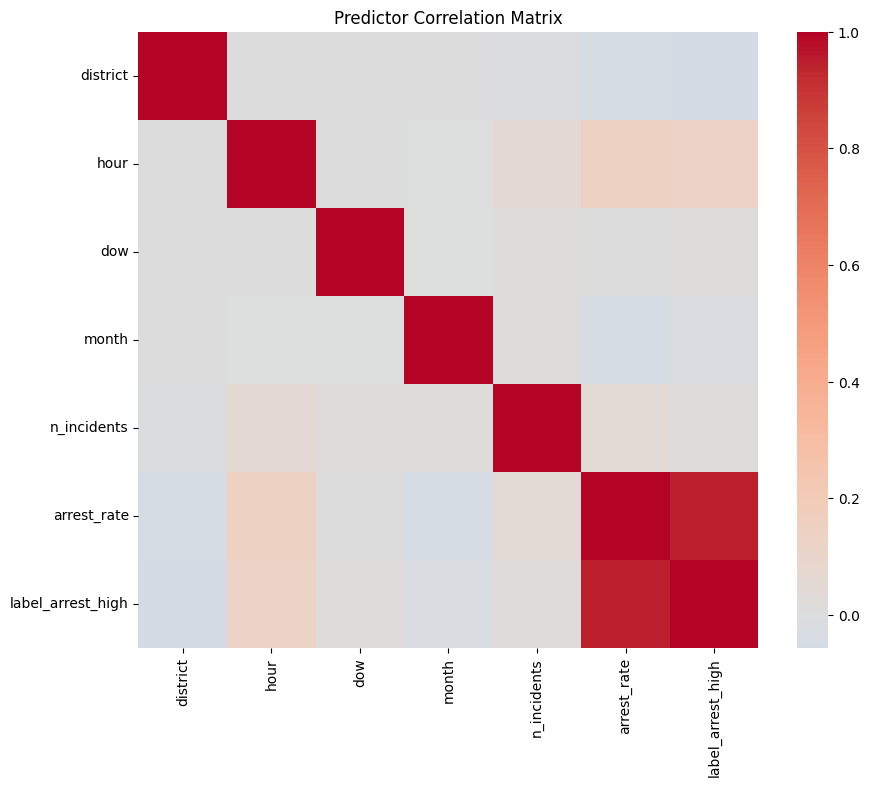

In [5]:
df_corr = df.copy().drop(columns=['primary_type'])
corr = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Predictor Correlation Matrix")
plt.show()

Classification to predict crime type using Random Forest

In [6]:
X = df.drop(columns=["primary_type", "label_arrest_high", "arrest_rate"]).copy()
y = df["label_arrest_high"].values

le = LabelEncoder()
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)

In [7]:
model = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1)
model.fit(X_train, y_train)
preds = model.predict(X_val)

In [8]:
print(classification_report(y_val, preds, target_names=["Low Arrest", "High Arrest"]))

              precision    recall  f1-score   support

  Low Arrest       0.90      1.00      0.95     23743
 High Arrest       0.92      0.09      0.17      2882

    accuracy                           0.90     26625
   macro avg       0.91      0.55      0.56     26625
weighted avg       0.90      0.90      0.86     26625



Look at accuracy and feature importance

Text(0.5, 1.0, 'Feature Importance')

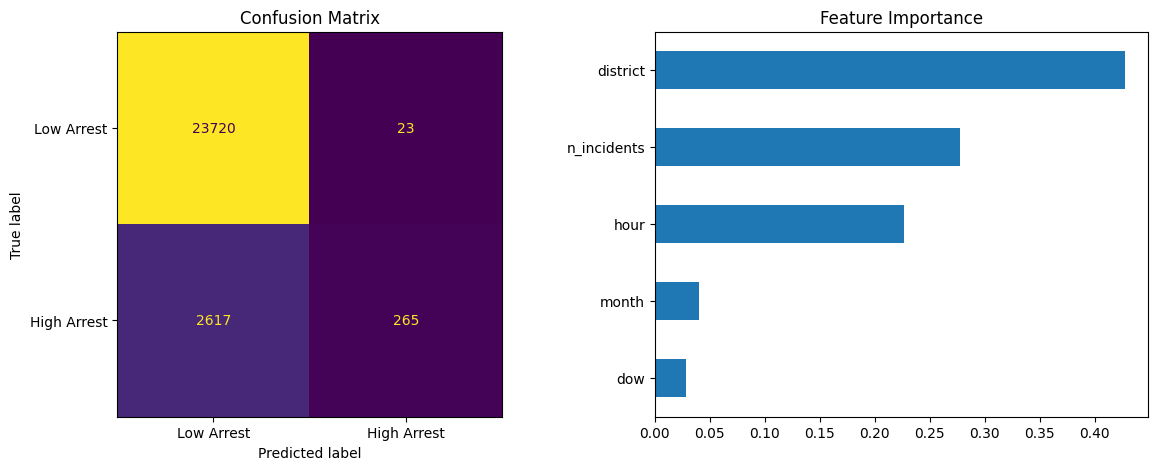

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_val, preds, display_labels=["Low Arrest", "High Arrest"],
    ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind="barh", ax=axes[1])
axes[1].set_title("Feature Importance")